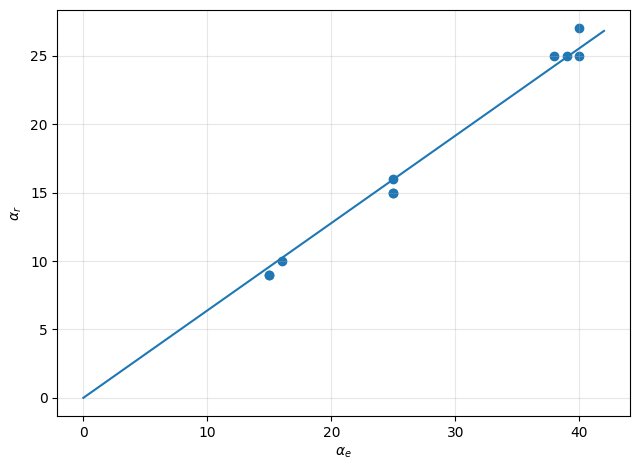

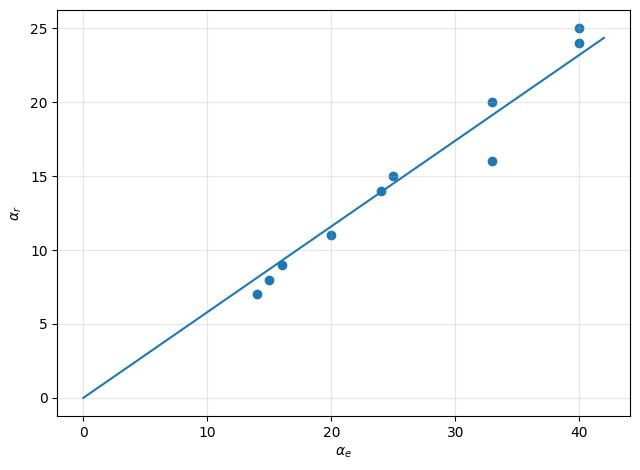

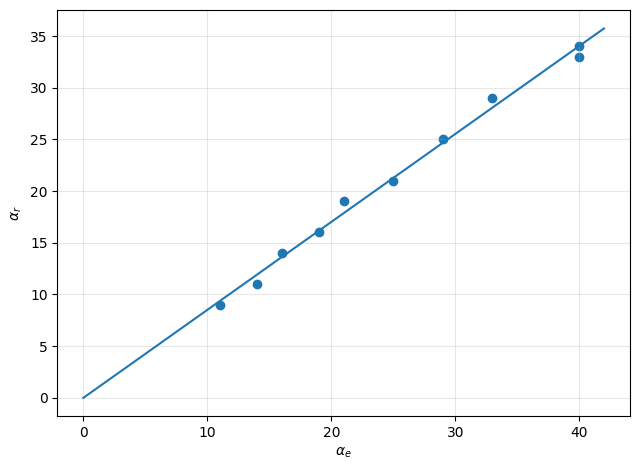

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


eps0 = 8.854e-12 

promjeri = {
    "d1": np.mean([9.5, 9.4, 9.5, 9.7, 9.4]),
    "d2": np.mean([9.9, 9.8, 9.9, 10.0, 9.9]),
    "d3": np.mean([3.0, 3.1, 3.0, 3.1, 3.0]),
}


mjerenja = {
    "d1": {
        "alpha_e": np.array([40, 25, 16, 38, 25, 15, 39, 25, 15, 40], dtype=float),
        "alpha_r": np.array([25, 16, 10, 25, 15, 9, 25, 15, 9, 27], dtype=float),
    },
    "d2": {
        "alpha_e": np.array([40, 25, 15, 33, 16, 40, 24, 14, 33, 20], dtype=float),
        "alpha_r": np.array([25, 15, 8, 16, 9, 24, 14, 7, 20, 11], dtype=float),
    },
    "d3": {
        "alpha_e": np.array([40, 33, 29, 25, 21, 19, 16, 14, 11, 40], dtype=float),
        "alpha_r": np.array([33, 29, 25, 21, 19, 16, 14, 11, 9, 34], dtype=float),
    },
}

out_dir = Path("/Users/margaretakoren/Desktop/pmfst/peti_semestar/PEiM/V1")
rezultati = []


for kugla, podaci in mjerenja.items():
    x = podaci["alpha_e"]
    y = podaci["alpha_r"]

    m = np.sum(x * y) / np.sum(x**2)
    y_fit = m * x

    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot

    r_m = (promjeri[kugla] / 2) * 1e-3
    Cr = 4 * np.pi * eps0 * r_m
    Ce = (m / (1 - m)) * Cr

    rezultati.append({
        "kugla": kugla,
        "m": m,
        "R2": r2,
        "Cr_F": Cr,
        "Cr_pF": Cr * 1e12,
        "Ce_F": Ce,
        "Ce_pF": Ce * 1e12,
    })

    # Graf
    x_line = np.linspace(0, max(x) * 1.05, 200)
    y_line = m * x_line

    plt.figure(figsize=(6.5, 4.8))
    plt.scatter(x, y,)
    plt.plot(x_line, y_line,)
    plt.xlabel(r"$\alpha_e$")
    plt.ylabel(r"$\alpha_r$")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / f"regresija_{kugla}.png", dpi=300)
    plt.show()

df = pd.DataFrame(rezultati)
df["Ce_znanstveno_F"] = df["Ce_F"].map(lambda v: f"{v:.3e}")
df.to_csv(out_dir / "regresija_rezultati_vjezba1.csv", index=False)